# Stage 2B — Neural Network Forecasting

## Objective

This stage applies neural-network-based time-series forecasting
to the customer's transaction data.

The neural models considered are:

1. GRU — primary neural forecasting model
2. LSTM — comparison model
3. Vanilla RNN — baseline model, if required

The objective is to forecast the customer's future credit amount
and compare the neural models using MAE, RMSE and MAPE.

The current six-month dataset is a simulated prototype dataset.
Therefore, neural-network results obtained from this dataset are
considered implementation/proof-of-concept results rather than
statistically conclusive performance estimates.

In [ ]:
# ============================================
# STAGE 2B — IMPORT LIBRARIES
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, LSTM, GRU, Dense

In [ ]:
# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("Random seeds set successfully.")

Random seeds set successfully.


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving customer_transactions_6_months_2026_with_share_market_flag.csv to customer_transactions_6_months_2026_with_share_market_flag.csv


In [ ]:
df = pd.read_csv("customer_transactions_6_months_2026.csv")

print("Dataset loaded successfully.")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully.
Shape: (181, 4)


,date,credit,debit,balance
0,2026-01-01,50000,401,69599
1,2026-01-02,0,236,69363
2,2026-01-03,0,796,68567
3,2026-01-04,0,653,67914
4,2026-01-05,0,12480,55434


In [ ]:
print("Column names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nFirst 5 rows:")
display(df.head())

Column names:
['date', 'credit', 'debit', 'balance']

Data types:
date       object
credit      int64
debit       int64
balance     int64
dtype: object

First 5 rows:


,date,credit,debit,balance
0,2026-01-01,50000,401,69599
1,2026-01-02,0,236,69363
2,2026-01-03,0,796,68567
3,2026-01-04,0,653,67914
4,2026-01-05,0,12480,55434


In [ ]:
df["date"] = pd.to_datetime(df["date"])

print(df.dtypes)

date       datetime64[ns]
credit              int64
debit               int64
balance             int64
dtype: object


In [ ]:
df["month"] = df["date"].dt.to_period("M")

In [ ]:
monthly = (
    df.groupby("month")
      .agg(
          total_credit=("credit", "sum"),
          total_debit=("debit", "sum"),
          closing_balance=("balance", "last")
      )
      .reset_index()
)

In [ ]:
monthly["net_flow"] = (
    monthly["total_credit"] -
    monthly["total_debit"]
)

In [ ]:
print("Monthly Transaction Summary")
print("===========================")

display(monthly)

Monthly Transaction Summary


,month,total_credit,total_debit,closing_balance,net_flow
0,2026-01,55000,41984,33016,13016
1,2026-02,54500,38286,49230,16214
2,2026-03,57000,41967,64263,15033
3,2026-04,56000,41930,78333,14070
4,2026-05,58500,48966,87867,9534
5,2026-06,59000,39111,107756,19889


In [ ]:
monthly_credits = monthly["total_credit"].copy()

print("Forecasting Target: Monthly Credit")
print("-----------------------------------")
print(monthly_credits)

Forecasting Target: Monthly Credit
-----------------------------------
0    55000
1    54500
2    57000
3    56000
4    58500
5    59000
Name: total_credit, dtype: int64


In [ ]:
train = monthly_credits.iloc[:5]
test = monthly_credits.iloc[5:]

actual_june = test.iloc[0]

print("Training Data")
print("=============")
print(train)

print("\nTest Data")
print("=========")
print(test)

print(f"\nActual June Credit: ₹{actual_june:,.2f}")

Training Data
0    55000
1    54500
2    57000
3    56000
4    58500
Name: total_credit, dtype: int64

Test Data
5    59000
Name: total_credit, dtype: int64

Actual June Credit: ₹59,000.00


In [ ]:
scaler = MinMaxScaler(feature_range=(0, 1))

train_values = train.values.reshape(-1, 1)

scaled_train = scaler.fit_transform(train_values)

print("Original Training Values:")
print(train_values.flatten())

print("\nScaled Training Values:")
print(scaled_train.flatten())

Original Training Values:
[55000 54500 57000 56000 58500]

Scaled Training Values:
[0.125 0.    0.625 0.375 1.   ]


In [ ]:
window_size = 3

X_train = []
y_train = []

for i in range(len(scaled_train) - window_size):

    X_train.append(
        scaled_train[i:i + window_size]
    )

    y_train.append(
        scaled_train[i + window_size]
    )

X_train = np.array(X_train)
y_train = np.array(y_train)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

X_train shape: (2, 3, 1)
y_train shape: (2, 1)


In [ ]:
prediction_input = scaled_train[-window_size:]

X_test = prediction_input.reshape(
    1,
    window_size,
    1
)

print("X_test shape:", X_test.shape)
print("\nX_test:")
print(X_test)

X_test shape: (1, 3, 1)

X_test:
[[[0.625]
  [0.375]
  [1.   ]]]


In [ ]:
print("\n======================================")
print("STAGE 2B — DATA PREPARATION COMPLETE")
print("======================================")

print(f"Total months       : {len(monthly_credits)}")
print(f"Training months    : {len(train)}")
print(f"Testing months     : {len(test)}")
print(f"Window size        : {window_size}")
print(f"Training sequences : {X_train.shape[0]}")
print(f"X_train shape      : {X_train.shape}")
print(f"y_train shape      : {y_train.shape}")
print(f"X_test shape       : {X_test.shape}")
print(f"Actual June credit : ₹{actual_june:,.2f}")


STAGE 2B — DATA PREPARATION COMPLETE
Total months       : 6
Training months    : 5
Testing months     : 1
Window size        : 3
Training sequences : 2
X_train shape      : (2, 3, 1)
y_train shape      : (2, 1)
X_test shape       : (1, 3, 1)
Actual June credit : ₹59,000.00


## Phase 2B.1 — Simple RNN Baseline

A Simple RNN (Vanilla RNN) is used as the baseline neural
forecasting model.

The model receives a sequence of previous monthly credit values
and learns the relationship between the previous months and the
next month's credit value.

Input:
3 previous months

Output:
1 predicted month

In [ ]:
# ============================================
# SIMPLE RNN MODEL
# ============================================

rnn_model = Sequential([
    SimpleRNN(
        units=16,
        activation="tanh",
        input_shape=(window_size, 1)
    ),
    Dense(1)
])

rnn_model.compile(
    optimizer="adam",
    loss="mse"
)

rnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 16)             │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 305 (1.19 KB)

 Trainable params: 305 (1.19 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ============================================
# TRAIN SIMPLE RNN
# ============================================

history_rnn = rnn_model.fit(
    X_train,
    y_train,
    epochs=200,
    batch_size=1,
    verbose=1
)

Epoch 1/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 0.5826
Epoch 2/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.5314
Epoch 3/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.4850 
Epoch 4/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.4410 
Epoch 5/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.3993 
Epoch 6/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.3597
Epoch 7/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.3222 
Epoch 8/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.2868
Epoch 9/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.2535 
Epoch 10/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.2224
Epoch 11/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.1935 
Epoch 12/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.1667 
Epoch 13/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.1422
Epoch 14/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.1199
Epoch 15/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0998
Epoch 16/200

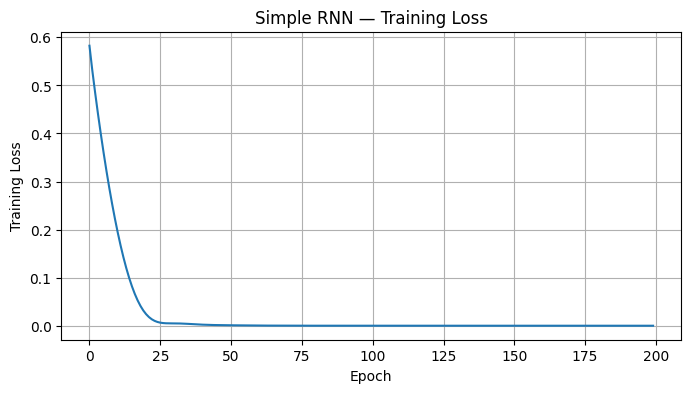

In [ ]:
plt.figure(figsize=(8, 4))

plt.plot(
    history_rnn.history["loss"]
)

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Simple RNN — Training Loss")

plt.grid(True)
plt.show()

In [ ]:
# ============================================
# SIMPLE RNN — JUNE FORECAST
# ============================================

# Predict using March → April → May
rnn_scaled_prediction = rnn_model.predict(X_test, verbose=0)

# Convert prediction back to actual ₹ value
rnn_prediction = scaler.inverse_transform(
    rnn_scaled_prediction
)[0][0]

print("Simple RNN Forecast")
print("===================")
print(f"Predicted June Credit : ₹{rnn_prediction:,.2f}")
print(f"Actual June Credit    : ₹{actual_june:,.2f}")

Simple RNN Forecast
Predicted June Credit : ₹57,026.42
Actual June Credit    : ₹59,000.00


In [ ]:
# ============================================
# SIMPLE RNN — EVALUATION
# ============================================

rnn_mae = mean_absolute_error(
    [actual_june],
    [rnn_prediction]
)

rnn_rmse = np.sqrt(
    mean_squared_error(
        [actual_june],
        [rnn_prediction]
    )
)

rnn_mape = (
    abs(actual_june - rnn_prediction)
    / abs(actual_june)
) * 100

print("\nSimple RNN Evaluation")
print("======================")
print(f"MAE  : ₹{rnn_mae:,.2f}")
print(f"RMSE : ₹{rnn_rmse:,.2f}")
print(f"MAPE : {rnn_mape:.4f}%")


Simple RNN Evaluation
MAE  : ₹1,973.58
RMSE : ₹1,973.58
MAPE : 3.3450%


In [ ]:
rnn_results = {
    "model": "Simple RNN",
    "forecast": rnn_prediction,
    "actual": actual_june,
    "MAE": rnn_mae,
    "RMSE": rnn_rmse,
    "MAPE": rnn_mape
}

print("\nStored Simple RNN Result")
print("========================")
print(rnn_results)


Stored Simple RNN Result
{'model': 'Simple RNN', 'forecast': np.float32(57026.42), 'actual': np.int64(59000), 'MAE': 1973.578125, 'RMSE': np.float64(1973.578125), 'MAPE': np.float64(3.345047669491526)}


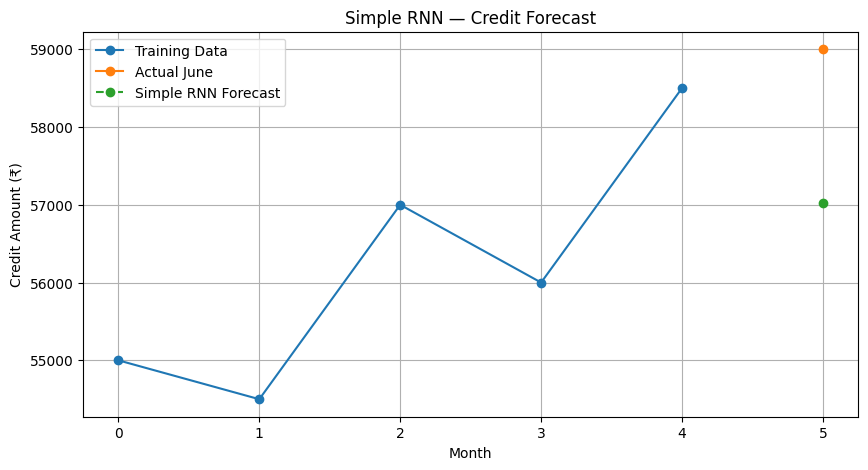

In [ ]:
# ============================================
# SIMPLE RNN — FORECAST VISUALIZATION
# ============================================

plt.figure(figsize=(10, 5))

plt.plot(
    range(len(train)),
    train.values,
    marker="o",
    label="Training Data"
)

plt.plot(
    len(train),
    actual_june,
    marker="o",
    label="Actual June"
)

plt.plot(
    len(train),
    rnn_prediction,
    marker="o",
    linestyle="--",
    label="Simple RNN Forecast"
)

plt.xlabel("Month")
plt.ylabel("Credit Amount (₹)")
plt.title("Simple RNN — Credit Forecast")

plt.legend()
plt.grid(True)

plt.show()

## Phase 2B.2 — LSTM Forecasting

LSTM (Long Short-Term Memory) is a gated recurrent neural network
designed to learn dependencies in sequential data.

Compared with the Simple RNN, LSTM introduces a memory mechanism
that helps control what information should be retained, forgotten,
and passed to the next step.

The same training and testing setup used for the Simple RNN will be
used so that the models can be compared fairly.

In [ ]:
# ============================================
# LSTM MODEL
# ============================================

lstm_model = Sequential([
    LSTM(
        units=16,
        activation="tanh",
        input_shape=(window_size, 1)
    ),
    Dense(1)
])

lstm_model.compile(
    optimizer="adam",
    loss="mse"
)

lstm_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 16)             │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,169 (4.57 KB)

 Trainable params: 1,169 (4.57 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ============================================
# TRAIN LSTM
# ============================================

history_lstm = lstm_model.fit(
    X_train,
    y_train,
    epochs=200,
    batch_size=1,
    verbose=1
)

Epoch 1/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 0.5788
Epoch 2/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.5657
Epoch 3/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.5532
Epoch 4/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.5410
Epoch 5/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.5292
Epoch 6/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.5176
Epoch 7/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.5062
Epoch 8/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.4949
Epoch 9/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.4839
Epoch 10/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.4730
Epoch 11/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.4622
Epoch 12/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.4514
Epoch 13/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.4408
Epoch 14/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.4302
Epoch 15/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.4196
Epoch 16/200
2/2 ━━

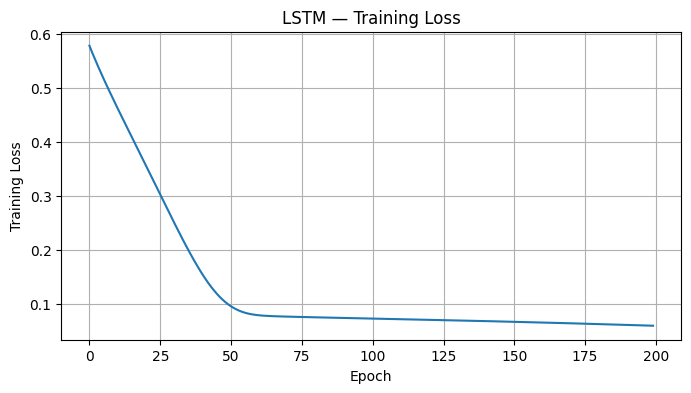

In [ ]:
# ============================================
# LSTM — TRAINING LOSS
# ============================================

plt.figure(figsize=(8, 4))

plt.plot(
    history_lstm.history["loss"]
)

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("LSTM — Training Loss")

plt.grid(True)
plt.show()

In [ ]:
# ============================================
# LSTM — JUNE FORECAST
# ============================================

lstm_scaled_prediction = lstm_model.predict(
    X_test,
    verbose=0
)

# Convert scaled prediction back to ₹
lstm_prediction = scaler.inverse_transform(
    lstm_scaled_prediction
)[0][0]

print("LSTM Forecast")
print("=============")
print(f"Predicted June Credit : ₹{lstm_prediction:,.2f}")
print(f"Actual June Credit    : ₹{actual_june:,.2f}")

LSTM Forecast
Predicted June Credit : ₹59,008.61
Actual June Credit    : ₹59,000.00


In [ ]:
# ============================================
# LSTM — EVALUATION
# ============================================

lstm_mae = mean_absolute_error(
    [actual_june],
    [lstm_prediction]
)

lstm_rmse = np.sqrt(
    mean_squared_error(
        [actual_june],
        [lstm_prediction]
    )
)

lstm_mape = (
    abs(actual_june - lstm_prediction)
    / abs(actual_june)
) * 100

print("\nLSTM Evaluation")
print("================")
print(f"MAE  : ₹{lstm_mae:,.2f}")
print(f"RMSE : ₹{lstm_rmse:,.2f}")
print(f"MAPE : {lstm_mape:.4f}%")


LSTM Evaluation
MAE  : ₹8.61
RMSE : ₹8.61
MAPE : 0.0146%


In [ ]:
lstm_results = {
    "model": "LSTM",
    "forecast": lstm_prediction,
    "actual": actual_june,
    "MAE": lstm_mae,
    "RMSE": lstm_rmse,
    "MAPE": lstm_mape
}

print("\nStored LSTM Result")
print("==================")
print(lstm_results)


Stored LSTM Result
{'model': 'LSTM', 'forecast': np.float32(59008.605), 'actual': np.int64(59000), 'MAE': 8.60546875, 'RMSE': np.float64(8.60546875), 'MAPE': np.float64(0.014585540254237288)}


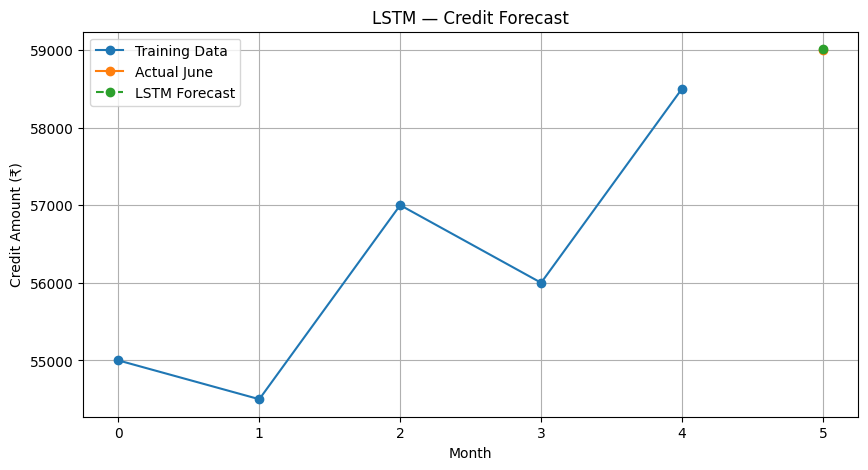

In [ ]:
# ============================================
# LSTM — FORECAST VISUALIZATION
# ============================================

plt.figure(figsize=(10, 5))

plt.plot(
    range(len(train)),
    train.values,
    marker="o",
    label="Training Data"
)

plt.plot(
    len(train),
    actual_june,
    marker="o",
    label="Actual June"
)

plt.plot(
    len(train),
    lstm_prediction,
    marker="o",
    linestyle="--",
    label="LSTM Forecast"
)

plt.xlabel("Month")
plt.ylabel("Credit Amount (₹)")
plt.title("LSTM — Credit Forecast")

plt.legend()
plt.grid(True)

plt.show()

## Phase 2B.3 — GRU Forecasting

GRU (Gated Recurrent Unit) is a gated recurrent neural network
designed to learn temporal dependencies in sequential data.

GRU uses a simpler gating mechanism than LSTM and generally has
fewer parameters. It is therefore selected as the primary neural
model for this prototype.

The same training, testing, scaling, sequence length and evaluation
procedure used for the Simple RNN and LSTM will be maintained for
a fair comparison.

In [ ]:
# ============================================
# GRU MODEL
# ============================================

gru_model = Sequential([
    GRU(
        units=16,
        activation="tanh",
        input_shape=(window_size, 1)
    ),
    Dense(1)
])

gru_model.compile(
    optimizer="adam",
    loss="mse"
)

gru_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 16)             │           912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 929 (3.63 KB)

 Trainable params: 929 (3.63 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ============================================
# GRU MODEL
# ============================================

from tensorflow.keras import Input

gru_model = Sequential([
    Input(shape=(window_size, 1)),

    GRU(
        units=16,
        activation="tanh"
    ),

    Dense(1)
])

gru_model.compile(
    optimizer="adam",
    loss="mse"
)

gru_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_1 (GRU)                     │ (None, 16)             │           912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 929 (3.63 KB)

 Trainable params: 929 (3.63 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ============================================
# TRAIN GRU
# ============================================

history_gru = gru_model.fit(
    X_train,
    y_train,
    epochs=200,
    batch_size=1,
    verbose=1
)

Epoch 1/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 0.7097
Epoch 2/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.6783
Epoch 3/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.6488
Epoch 4/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.6205
Epoch 5/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.5933
Epoch 6/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.5671
Epoch 7/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.5419
Epoch 8/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.5175
Epoch 9/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.4941
Epoch 10/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.4714
Epoch 11/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.4496
Epoch 12/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.4285
Epoch 13/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.4082
Epoch 14/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.3886
Epoch 15/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.3697
Epoch 16/200
2/2 ━━

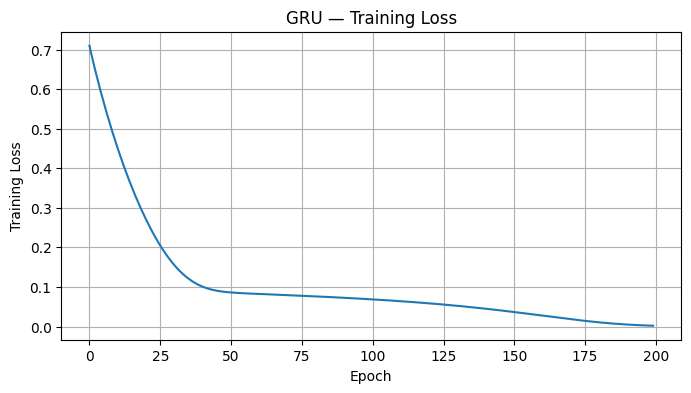

In [ ]:
# ============================================
# GRU — TRAINING LOSS
# ============================================

plt.figure(figsize=(8, 4))

plt.plot(
    history_gru.history["loss"]
)

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("GRU — Training Loss")

plt.grid(True)
plt.show()

In [ ]:
# ============================================
# GRU — JUNE FORECAST
# ============================================

gru_scaled_prediction = gru_model.predict(
    X_test,
    verbose=0
)

# Convert prediction back to actual ₹
gru_prediction = scaler.inverse_transform(
    gru_scaled_prediction
)[0][0]

print("GRU Forecast")
print("============")
print(f"Predicted June Credit : ₹{gru_prediction:,.2f}")
print(f"Actual June Credit    : ₹{actual_june:,.2f}")

GRU Forecast
Predicted June Credit : ₹57,619.36
Actual June Credit    : ₹59,000.00


In [ ]:
# ============================================
# GRU — EVALUATION
# ============================================

gru_mae = mean_absolute_error(
    [actual_june],
    [gru_prediction]
)

gru_rmse = np.sqrt(
    mean_squared_error(
        [actual_june],
        [gru_prediction]
    )
)

gru_mape = (
    abs(actual_june - gru_prediction)
    / abs(actual_june)
) * 100

print("\nGRU Evaluation")
print("==============")
print(f"MAE  : ₹{gru_mae:,.2f}")
print(f"RMSE : ₹{gru_rmse:,.2f}")
print(f"MAPE : {gru_mape:.4f}%")


GRU Evaluation
MAE  : ₹1,380.64
RMSE : ₹1,380.64
MAPE : 2.3401%


In [ ]:
# ============================================
# STORE GRU RESULT
# ============================================

gru_results = {
    "model": "GRU",
    "forecast": gru_prediction,
    "actual": actual_june,
    "MAE": gru_mae,
    "RMSE": gru_rmse,
    "MAPE": gru_mape
}

print("\nStored GRU Result")
print("=================")
print(gru_results)


Stored GRU Result
{'model': 'GRU', 'forecast': np.float32(57619.363), 'actual': np.int64(59000), 'MAE': 1380.63671875, 'RMSE': np.float64(1380.63671875), 'MAPE': np.float64(2.3400622351694915)}


In [ ]:
print("Simple RNN:", rnn_results)
print("LSTM:", lstm_results)
print("GRU:", gru_results)

Simple RNN: {'model': 'Simple RNN', 'forecast': np.float32(57026.42), 'actual': np.int64(59000), 'MAE': 1973.578125, 'RMSE': np.float64(1973.578125), 'MAPE': np.float64(3.345047669491526)}
LSTM: {'model': 'LSTM', 'forecast': np.float32(59008.605), 'actual': np.int64(59000), 'MAE': 8.60546875, 'RMSE': np.float64(8.60546875), 'MAPE': np.float64(0.014585540254237288)}
GRU: {'model': 'GRU', 'forecast': np.float32(57619.363), 'actual': np.int64(59000), 'MAE': 1380.63671875, 'RMSE': np.float64(1380.63671875), 'MAPE': np.float64(2.3400622351694915)}


In [ ]:
# ============================================
# NEURAL MODEL COMPARISON
# ============================================

neural_comparison = pd.DataFrame([
    rnn_results,
    lstm_results,
    gru_results
])

# Sort by MAPE — lower is better
neural_comparison = (
    neural_comparison
    .sort_values("MAPE")
    .reset_index(drop=True)
)

# Add ranking
neural_comparison["Rank"] = (
    neural_comparison.index + 1
)

# Reorder columns
neural_comparison = neural_comparison[
    [
        "Rank",
        "model",
        "forecast",
        "actual",
        "MAE",
        "RMSE",
        "MAPE"
    ]
]

print("==============================================")
print("STAGE 2B — NEURAL MODEL COMPARISON")
print("==============================================")

display(neural_comparison)

STAGE 2B — NEURAL MODEL COMPARISON


,Rank,model,forecast,actual,MAE,RMSE,MAPE
0,1,LSTM,59008.605469,59000,8.605469,8.605469,0.014586
1,2,GRU,57619.363281,59000,1380.636719,1380.636719,2.340062
2,3,Simple RNN,57026.421875,59000,1973.578125,1973.578125,3.345048


In [ ]:
best_neural = neural_comparison.iloc[0]

print("\nBest Neural Model")
print("=================")
print(f"Model    : {best_neural['model']}")
print(f"Forecast : ₹{best_neural['forecast']:,.2f}")
print(f"Actual   : ₹{best_neural['actual']:,.2f}")
print(f"MAE      : ₹{best_neural['MAE']:,.2f}")
print(f"RMSE     : ₹{best_neural['RMSE']:,.2f}")
print(f"MAPE     : {best_neural['MAPE']:.4f}%")


Best Neural Model
Model    : LSTM
Forecast : ₹59,008.61
Actual   : ₹59,000.00
MAE      : ₹8.61
RMSE     : ₹8.61
MAPE     : 0.0146%


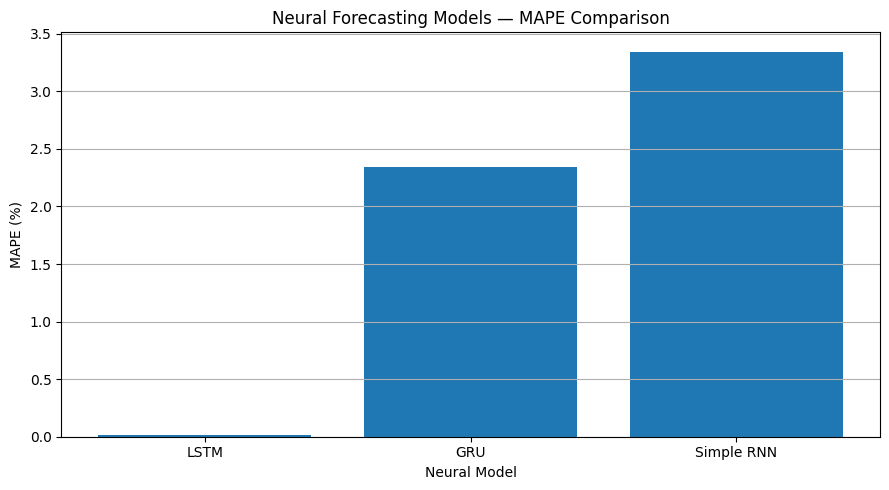

In [ ]:
# ============================================
# NEURAL MODEL — MAPE COMPARISON
# ============================================

plt.figure(figsize=(9, 5))

plt.bar(
    neural_comparison["model"],
    neural_comparison["MAPE"]
)

plt.xlabel("Neural Model")
plt.ylabel("MAPE (%)")
plt.title("Neural Forecasting Models — MAPE Comparison")

plt.grid(axis="y")
plt.tight_layout()

plt.show()

In [ ]:
# ============================================
# RESTORE STAGE 2A RESULTS
# ============================================

arima_results = {
    "model": "ARIMA(1,1,1)",
    "forecast": 56900.90941779743,
    "actual": 59000,
    "MAE": 2099.090582202567,
    "RMSE": 2099.090582202567,
    "MAPE": 3.5577806478009606
}

sarima_results = {
    "model": "SARIMA(1,1,1)(1,1,1,2)",
    "forecast": 57499.999999999985,
    "actual": 59000,
    "MAE": 1500.0000000000146,
    "RMSE": 1500.0000000000146,
    "MAPE": 2.542372881355957
}

ets_results = {
    "model": "ETS (Holt's Double)",
    "forecast": 59019.841302943605,
    "actual": 59000,
    "MAE": 19.841302943605115,
    "RMSE": 19.841302943605115,
    "MAPE": 0.03362932702305951
}

print("Stage 2A results restored successfully.")

Stage 2A results restored successfully.


In [ ]:
print("Simple RNN:", rnn_results)
print("LSTM:", lstm_results)
print("GRU:", gru_results)

Simple RNN: {'model': 'Simple RNN', 'forecast': np.float32(57026.42), 'actual': np.int64(59000), 'MAE': 1973.578125, 'RMSE': np.float64(1973.578125), 'MAPE': np.float64(3.345047669491526)}
LSTM: {'model': 'LSTM', 'forecast': np.float32(59008.605), 'actual': np.int64(59000), 'MAE': 8.60546875, 'RMSE': np.float64(8.60546875), 'MAPE': np.float64(0.014585540254237288)}
GRU: {'model': 'GRU', 'forecast': np.float32(57619.363), 'actual': np.int64(59000), 'MAE': 1380.63671875, 'RMSE': np.float64(1380.63671875), 'MAPE': np.float64(2.3400622351694915)}


In [ ]:
# ============================================
# STAGE 2 — OVERALL MODEL COMPARISON
# ============================================

all_results = [
    arima_results,
    sarima_results,
    ets_results,
    rnn_results,
    lstm_results,
    gru_results
]

comparison = pd.DataFrame(all_results)

# Lower MAPE = better
comparison = (
    comparison
    .sort_values("MAPE")
    .reset_index(drop=True)
)

comparison["Rank"] = comparison.index + 1

# Identify model type
traditional_models = [
    "ARIMA(1,1,1)",
    "SARIMA(1,1,1)(1,1,1,2)",
    "ETS (Holt's Double)"
]

comparison["Type"] = comparison["model"].apply(
    lambda x: "Traditional"
    if x in traditional_models
    else "Neural"
)

comparison = comparison[
    [
        "Rank",
        "model",
        "Type",
        "forecast",
        "actual",
        "MAE",
        "RMSE",
        "MAPE"
    ]
]

print("======================================================")
print("STAGE 2 — OVERALL FORECASTING MODEL COMPARISON")
print("======================================================")

display(comparison)

STAGE 2 — OVERALL FORECASTING MODEL COMPARISON


,Rank,model,Type,forecast,actual,MAE,RMSE,MAPE
0,1,LSTM,Neural,59008.605469,59000,8.605469,8.605469,0.014586
1,2,ETS (Holt's Double),Traditional,59019.841303,59000,19.841303,19.841303,0.033629
2,3,GRU,Neural,57619.363281,59000,1380.636719,1380.636719,2.340062
3,4,"SARIMA(1,1,1)(1,1,1,2)",Traditional,57500.000000,59000,1500.000000,1500.000000,2.542373
4,5,Simple RNN,Neural,57026.421875,59000,1973.578125,1973.578125,3.345048
5,6,"ARIMA(1,1,1)",Traditional,56900.909418,59000,2099.090582,2099.090582,3.557781


In [ ]:
# ============================================
# BEST OVERALL MODEL
# ============================================

best_model = comparison.iloc[0]

print("\nBest Overall Model")
print("==================")
print(f"Model    : {best_model['model']}")
print(f"Type     : {best_model['Type']}")
print(f"Forecast : ₹{best_model['forecast']:,.2f}")
print(f"Actual   : ₹{best_model['actual']:,.2f}")
print(f"MAE      : ₹{best_model['MAE']:,.2f}")
print(f"RMSE     : ₹{best_model['RMSE']:,.2f}")
print(f"MAPE     : {best_model['MAPE']:.4f}%")


Best Overall Model
Model    : LSTM
Type     : Neural
Forecast : ₹59,008.61
Actual   : ₹59,000.00
MAE      : ₹8.61
RMSE     : ₹8.61
MAPE     : 0.0146%


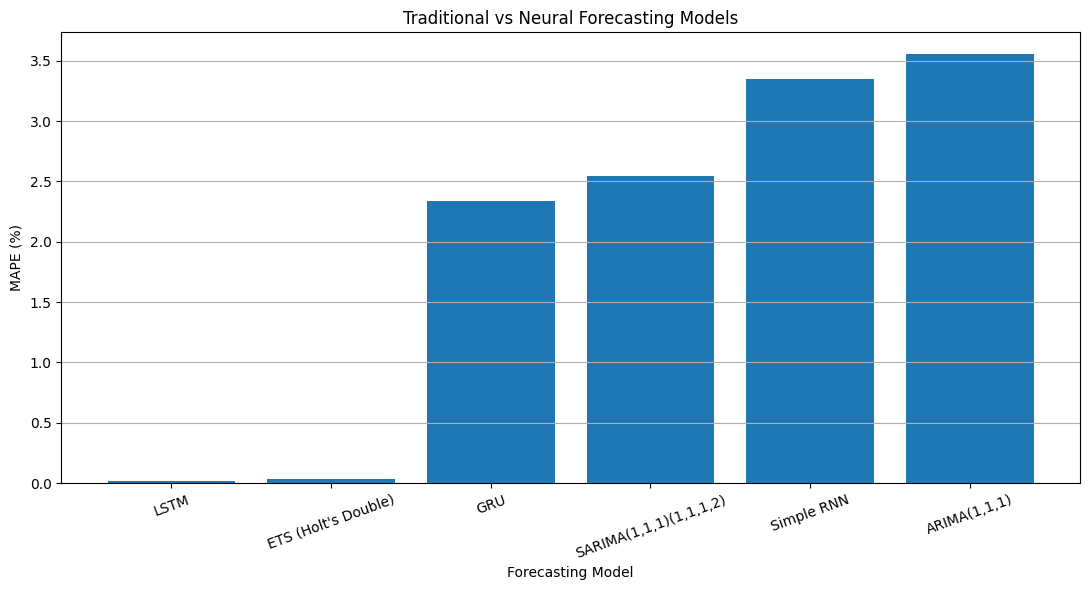

In [ ]:
# ============================================
# OVERALL MAPE COMPARISON
# ============================================

plt.figure(figsize=(11, 6))

plt.bar(
    comparison["model"],
    comparison["MAPE"]
)

plt.xlabel("Forecasting Model")
plt.ylabel("MAPE (%)")
plt.title("Traditional vs Neural Forecasting Models")

plt.xticks(rotation=20)
plt.grid(axis="y")

plt.tight_layout()
plt.show()

In [ ]:
print("\n==============================================")
print("FINAL MODEL RANKING")
print("==============================================")

for _, row in comparison.iterrows():
    print(
        f"{int(row['Rank'])}. "
        f"{row['model']} ({row['Type']}) "
        f"→ MAPE: {row['MAPE']:.4f}%"
    )


FINAL MODEL RANKING
1. LSTM (Neural) → MAPE: 0.0146%
2. ETS (Holt's Double) (Traditional) → MAPE: 0.0336%
3. GRU (Neural) → MAPE: 2.3401%
4. SARIMA(1,1,1)(1,1,1,2) (Traditional) → MAPE: 2.5424%
5. Simple RNN (Neural) → MAPE: 3.3450%
6. ARIMA(1,1,1) (Traditional) → MAPE: 3.5578%


In [ ]:
import os

print(os.listdir())

['.config', 'sample_data']


In [ ]:
# ============================================================
# LOAD DATA + CALCULATE OVERALL CREDIT-DEBIT SURPLUS %
# ============================================================

import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 1. Load your verified transaction dataset
# ------------------------------------------------------------

file_path = "customer_transactions_6_months_2026_with_share_market_flag.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully.")
print(f"Rows    : {len(df)}")
print(f"Columns : {list(df.columns)}")


# ------------------------------------------------------------
# 2. Check required columns
# ------------------------------------------------------------

required_columns = ["credit", "debit"]

missing_columns = [
    col for col in required_columns
    if col not in df.columns
]

if missing_columns:
    raise ValueError(
        f"Missing required columns: {missing_columns}"
    )


# ------------------------------------------------------------
# 3. Convert credit and debit to numeric
# ------------------------------------------------------------

df["credit"] = pd.to_numeric(
    df["credit"],
    errors="coerce"
).fillna(0)

df["debit"] = pd.to_numeric(
    df["debit"],
    errors="coerce"
).fillna(0)


# ------------------------------------------------------------
# 4. Calculate totals
# ------------------------------------------------------------

total_credit = df["credit"].sum()
total_debit = df["debit"].sum()

net_surplus = total_credit - total_debit


# ------------------------------------------------------------
# 5. Calculate surplus percentage
# ------------------------------------------------------------

if total_credit > 0:
    surplus_percentage = (
        net_surplus / total_credit
    ) * 100
else:
    surplus_percentage = 0


# ------------------------------------------------------------
# 6. Display result
# ------------------------------------------------------------

print()
print("=" * 60)
print("OVERALL CREDIT-DEBIT SURPLUS")
print("=" * 60)

print(f"Total Credit : ₹{total_credit:,.2f}")
print(f"Total Debit  : ₹{total_debit:,.2f}")
print(f"Net Surplus  : ₹{net_surplus:,.2f}")
print(f"Surplus %    : {surplus_percentage:.2f}%")

print("=" * 60)

Dataset loaded successfully.
Rows    : 181
Columns : ['date', 'credit', 'debit', 'balance', 'share_market_flag']

OVERALL CREDIT-DEBIT SURPLUS
Total Credit : ₹340,000.00
Total Debit  : ₹252,244.00
Net Surplus  : ₹87,756.00
Surplus %    : 25.81%


In [ ]:
# ============================================================
# FINAL FORECASTING RESULTS REPORT — PDF EXPORT
# ============================================================

!pip install reportlab -q
import pandas as pd
from datetime import datetime

from reportlab.lib.pagesizes import A4
from reportlab.platypus import (
    SimpleDocTemplate,
    Paragraph,
    Spacer,
    Table,
    TableStyle
)
from reportlab.lib import colors
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib.enums import TA_CENTER
from reportlab.lib.units import mm


# ============================================================
# 1. COLLECT YOUR ACTUAL MODEL RESULTS
# ============================================================

results = [
    arima_result,
    sarima_result,
    ets_result,
    rnn_result,
    lstm_result,
    gru_result
]

comparison = pd.DataFrame(results)


# ============================================================
# 2. MODEL TYPES
# ============================================================

traditional_models = [
    "ARIMA(1,1,1)",
    "SARIMA(1,1,1)(1,1,1,2)",
    "ETS (Holt's Double)"
]

comparison["Type"] = comparison["model"].apply(
    lambda x:
    "Traditional"
    if x in traditional_models
    else "Neural"
)


# ============================================================
# 3. CALCULATE RMSE
# ============================================================

comparison["RMSE"] = (
    (comparison["forecast"] - comparison["actual"]) ** 2
) ** 0.5


# ============================================================
# 4. RANK BY MAPE
# ============================================================

comparison = comparison.sort_values(
    "MAPE"
).reset_index(drop=True)

comparison["Rank"] = comparison.index + 1

best = comparison.iloc[0]


# ============================================================
# 5. CREATE PDF
# ============================================================

pdf_filename = "Forecasting_Results_Report.pdf"

doc = SimpleDocTemplate(
    pdf_filename,
    pagesize=A4,
    rightMargin=15 * mm,
    leftMargin=15 * mm,
    topMargin=15 * mm,
    bottomMargin=15 * mm
)


# ============================================================
# 6. STYLES
# ============================================================

styles = getSampleStyleSheet()

title_style = ParagraphStyle(
    "ReportTitle",
    parent=styles["Title"],
    fontSize=18,
    alignment=TA_CENTER,
    spaceAfter=12
)

section_style = ParagraphStyle(
    "Section",
    parent=styles["Heading2"],
    fontSize=12,
    spaceBefore=10,
    spaceAfter=6
)

body_style = ParagraphStyle(
    "Body",
    parent=styles["BodyText"],
    fontSize=9,
    leading=12
)


story = []


# ============================================================
# 7. TITLE
# ============================================================

story.append(
    Paragraph(
        "FORECASTING RESULTS REPORT",
        title_style
    )
)

story.append(
    Paragraph(
        f"<b>Report Date:</b> "
        f"{datetime.now().strftime('%d-%m-%Y')}<br/>"
        f"<b>Forecast Target:</b> Monthly Total Credit<br/>"
        f"<b>Test Month:</b> June 2026<br/>"
        f"<b>Actual June Credit:</b> ₹59,000.00",
        body_style
    )
)

story.append(Spacer(1, 10))


# ============================================================
# 8. STAGE 2A — TRADITIONAL MODELS
# ============================================================

story.append(
    Paragraph(
        "STAGE 2A — TRADITIONAL FORECASTING MODELS",
        section_style
    )
)

traditional = comparison[
    comparison["Type"] == "Traditional"
]

traditional_table = [
    [
        "Model",
        "Forecast",
        "MAE",
        "RMSE",
        "MAPE"
    ]
]

for _, row in traditional.iterrows():

    traditional_table.append([
        row["model"],
        f"₹{float(row['forecast']):,.2f}",
        f"₹{float(row['MAE']):,.2f}",
        f"₹{float(row['RMSE']):,.2f}",
        f"{float(row['MAPE']):.4f}%"
    ])


table = Table(
    traditional_table,
    repeatRows=1,
    colWidths=[
        65 * mm,
        27 * mm,
        27 * mm,
        27 * mm,
        20 * mm
    ]
)

table.setStyle(
    TableStyle([
        ("BACKGROUND", (0, 0), (-1, 0), colors.lightgrey),
        ("FONTNAME", (0, 0), (-1, 0), "Helvetica-Bold"),
        ("GRID", (0, 0), (-1, -1), 0.5, colors.grey),
        ("FONTSIZE", (0, 0), (-1, -1), 8),
        ("ALIGN", (1, 1), (-1, -1), "RIGHT"),
        ("VALIGN", (0, 0), (-1, -1), "MIDDLE"),
        ("TOPPADDING", (0, 0), (-1, -1), 5),
        ("BOTTOMPADDING", (0, 0), (-1, -1), 5)
    ])
)

story.append(table)
story.append(Spacer(1, 10))


# ============================================================
# 9. STAGE 2B — NEURAL MODELS
# ============================================================

story.append(
    Paragraph(
        "STAGE 2B — NEURAL FORECASTING MODELS",
        section_style
    )
)

neural = comparison[
    comparison["Type"] == "Neural"
]

neural_table = [
    [
        "Model",
        "Forecast",
        "MAE",
        "RMSE",
        "MAPE"
    ]
]

for _, row in neural.iterrows():

    neural_table.append([
        row["model"],
        f"₹{float(row['forecast']):,.2f}",
        f"₹{float(row['MAE']):,.2f}",
        f"₹{float(row['RMSE']):,.2f}",
        f"{float(row['MAPE']):.4f}%"
    ])


table = Table(
    neural_table,
    repeatRows=1,
    colWidths=[
        65 * mm,
        27 * mm,
        27 * mm,
        27 * mm,
        20 * mm
    ]
)

table.setStyle(
    TableStyle([
        ("BACKGROUND", (0, 0), (-1, 0), colors.lightgrey),
        ("FONTNAME", (0, 0), (-1, 0), "Helvetica-Bold"),
        ("GRID", (0, 0), (-1, -1), 0.5, colors.grey),
        ("FONTSIZE", (0, 0), (-1, -1), 8),
        ("ALIGN", (1, 1), (-1, -1), "RIGHT"),
        ("VALIGN", (0, 0), (-1, -1), "MIDDLE"),
        ("TOPPADDING", (0, 0), (-1, -1), 5),
        ("BOTTOMPADDING", (0, 0), (-1, -1), 5)
    ])
)

story.append(table)
story.append(Spacer(1, 10))


# ============================================================
# 10. FINAL MODEL RANKING
# ============================================================

story.append(
    Paragraph(
        "FINAL MODEL RANKING",
        section_style
    )
)

ranking_table = [
    [
        "Rank",
        "Model",
        "Type",
        "Forecast",
        "MAPE"
    ]
]

for _, row in comparison.iterrows():

    ranking_table.append([
        str(int(row["Rank"])),
        row["model"],
        row["Type"],
        f"₹{float(row['forecast']):,.2f}",
        f"{float(row['MAPE']):.4f}%"
    ])


table = Table(
    ranking_table,
    repeatRows=1,
    colWidths=[
        15 * mm,
        65 * mm,
        30 * mm,
        35 * mm,
        22 * mm
    ]
)

table.setStyle(
    TableStyle([
        ("BACKGROUND", (0, 0), (-1, 0), colors.lightgrey),
        ("FONTNAME", (0, 0), (-1, 0), "Helvetica-Bold"),
        ("GRID", (0, 0), (-1, -1), 0.5, colors.grey),
        ("FONTSIZE", (0, 0), (-1, -1), 8),
        ("ALIGN", (0, 0), (0, -1), "CENTER"),
        ("ALIGN", (3, 1), (-1, -1), "RIGHT"),
        ("VALIGN", (0, 0), (-1, -1), "MIDDLE"),
        ("TOPPADDING", (0, 0), (-1, -1), 5),
        ("BOTTOMPADDING", (0, 0), (-1, -1), 5)
    ])
)

story.append(table)
story.append(Spacer(1, 10))


# ============================================================
# 11. BEST MODEL
# ============================================================

story.append(
    Paragraph(
        "BEST PERFORMING MODEL",
        section_style
    )
)

story.append(
    Paragraph(
        f"<b>Model:</b> {best['model']}<br/>"
        f"<b>Type:</b> {best['Type']}<br/>"
        f"<b>Forecast:</b> ₹{float(best['forecast']):,.2f}<br/>"
        f"<b>Actual:</b> ₹{float(best['actual']):,.2f}<br/>"
        f"<b>MAE:</b> ₹{float(best['MAE']):,.2f}<br/>"
        f"<b>RMSE:</b> ₹{float(best['RMSE']):,.2f}<br/>"
        f"<b>MAPE:</b> {float(best['MAPE']):.4f}%",
        body_style
    )
)

story.append(Spacer(1, 8))


# ============================================================
# 12. FORECASTING SETUP
# ============================================================

story.append(
    Paragraph(
        "FORECASTING SETUP",
        section_style
    )
)

story.append(
    Paragraph(
        "<b>Total Months:</b> 6<br/>"
        "<b>Training Months:</b> 5<br/>"
        "<b>Testing Months:</b> 1<br/>"
        "<b>Test Observation:</b> June 2026<br/>"
        "<b>Actual June Credit:</b> ₹59,000.00",
        body_style
    )
)

story.append(Spacer(1, 8))


# ============================================================
# 13. METRICS
# ============================================================

story.append(
    Paragraph(
        "EVALUATION METRICS",
        section_style
    )
)

story.append(
    Paragraph(
        "<b>MAE</b> — Mean Absolute Error<br/>"
        "<b>RMSE</b> — Root Mean Squared Error<br/>"
        "<b>MAPE</b> — Mean Absolute Percentage Error<br/><br/>"
        "Lower values indicate better forecasting performance.",
        body_style
    )
)

story.append(Spacer(1, 8))

story.append(
    Paragraph(
        "<b>Note:</b> The current experiment contains one held-out "
        "test observation, so the metrics represent performance "
        "on this particular test split.",
        body_style
    )
)

# ============================================================
# PROFIT / SURPLUS %
# ============================================================

story.append(
    Paragraph(
        "OVERALL TRANSACTION SURPLUS",
        section_style
    )
)

story.append(
    Paragraph(
        f"<b>Total Credit:</b> ₹{total_credit:,.2f}<br/>"
        f"<b>Total Debit:</b> ₹{total_debit:,.2f}<br/>"
        f"<b>Net Surplus:</b> ₹{net_surplus:,.2f}<br/>"
        f"<b>Surplus / Profit %:</b> {surplus_percentage:.2f}%",
        body_style
    )
)

story.append(Spacer(1, 8))

story.append(
    Paragraph(
        "<b>Calculation:</b><br/>"
        "(Total Credit − Total Debit) / Total Credit × 100",
        body_style
    )
)


# ============================================================
# 14. BUILD PDF
# ============================================================

doc.build(story)


# ============================================================
# 15. CONFIRM
# ============================================================

print("=" * 70)
print("FORECASTING PDF GENERATED SUCCESSFULLY")
print("=" * 70)
print()
print(f"File: {pdf_filename}")
print()
print("Download it from the Colab Files panel:")
print(f"→ {pdf_filename}")

from google.colab import files

files.download("Forecasting_Results_Report.pdf")

FORECASTING PDF GENERATED SUCCESSFULLY

File: Forecasting_Results_Report.pdf

Download it from the Colab Files panel:
→ Forecasting_Results_Report.pdf


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>